In [17]:
using CSV
using DataFrames
using Serialization
# using HDF5
using Statistics
using Plots

In [18]:
df = DataFrame(CSV.File("../real_network/cleaned_adjacency_matrix.csv"));
population_sizes = Dict(
    "PEK" => 16_938_000,
    "LHR" => 9_800_000,
    "CGK" => 9_733_000,
    "DEL" => 16_787_941,
    "BOM" => 12_442_373,
    "ATL" => 4_661_000,
    "HND" => 36_975_000,
    "BKK" => 8_484_000,
    "CDG" => 10_514_000,
    "CAN" => 10_546_000,
    "PVG" => 20_948_000,
    "SIN" => 5_176_000,
    "LAX" => 12_197_000,
    "KUL" => 6_005_000,
    "CTU" => 7_570_000,
    "AMS" => 1_073_000,
    "GRU" => 11_310_000,
    "DEN" => 2_428_000,
    "HKG" => 7_066_000,
    "MNL" => 12_075_689,
    "SHA" => 23_019_148,
    "SFO" => 4_335_391,
    "MUC" => 3_000_000,
    "MAD" => 5_256_249,
    "JFK" => 18_920_000,
    "IST" => 13_200_000,
    "ICN" => 2_559_000,
    "DXB" => 1_875_000,
    "FCO" => 3_997_465,
    "FRA" => 2_300_000
);

In [19]:
real_migration_matrix = Matrix(df)[:,1:end-1]

30×30 Matrix{Float64}:
 0.0          0.000580608  0.000442325  …  9.01128e-8   0.000554007
 0.00267908   0.0          7.40452e-6      0.0          1.18271e-5
 0.00341333   1.17839e-5   0.0             2.54987e-6   0.00223587
 0.00160866   5.71466e-6   0.000803773     3.4795e-9    0.00159625
 4.57523e-5   3.54992e-6   0.00118423      0.000535569  0.00107726
 0.00321608   0.000783349  0.000500578  …  6.48917e-8   0.000720303
 2.08178e-5   1.03663e-6   0.000521953     1.25692e-6   0.00163804
 0.000757617  8.26367e-7   9.72532e-5      2.00017e-5   0.00024173
 0.00164613   5.76783e-6   0.000897723     8.35709e-7   0.00112351
 2.35718e-5   0.00327707   6.51302e-7      0.0          1.61105e-6
 ⋮                                      ⋱               
 0.00496963   0.000707796  0.000666801     5.35158e-8   0.00095854
 0.00458669   0.000291445  0.000114628     6.63591e-8   1.82312e-5
 0.0013152    2.36589e-6   0.000889049     1.45821e-6   0.00144975
 0.00332821   0.00036104   0.000292063     3.18

In [23]:
migration_rates = []
for i = 1:30
    for j=1:30
        if i==j
            continue
        else
            push!(migration_rates, real_migration_matrix[i,j])
        end
    end
end

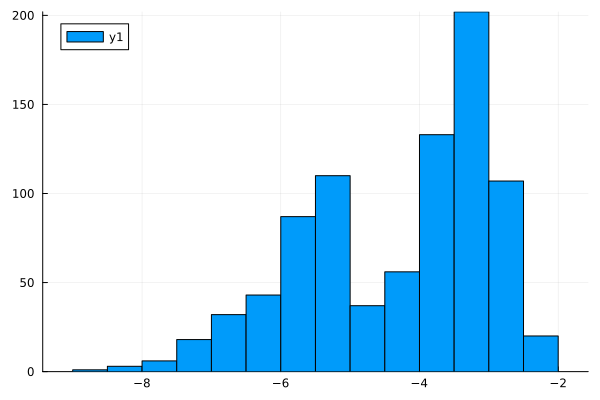

In [24]:
barhist(log10.(migration_rates))

In [25]:
bootstrapped_migration_matrix = fill(NaN, 30, 30)

30×30 Matrix{Float64}:
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  …  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
   ⋮                        ⋮            ⋱              ⋮                 
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     

In [33]:
for i=1:30
    for j=1:30
        if i==j 
            bootstrapped_migration_matrix[i,j] = 0.0
        else
            bootstrapped_migration_matrix[i,j] = migration_rates[rand(1:length(migration_rates))]
        end
    end
end

In [35]:
bootstrapped_migration_rates = []
for i = 1:30
    for j=1:30
        if i==j
            continue
        else
            push!(bootstrapped_migration_rates, bootstrapped_migration_matrix[i,j])
        end
    end
end

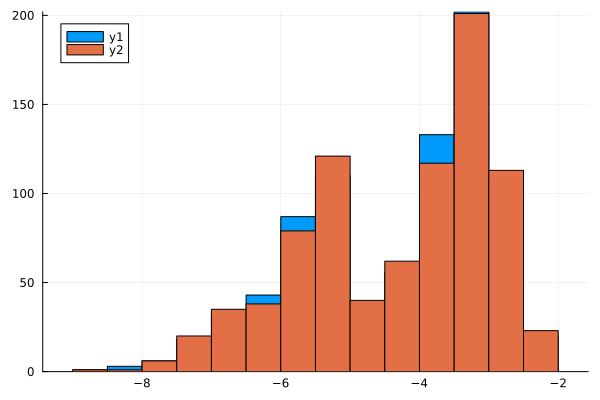

In [36]:
barhist!(log10.(bootstrapped_migration_rates))

In [38]:
df = DataFrame(bootstrapped_migration_matrix,:auto)
CSV.write("bootstrapped_migration_matrix.csv", df)

"bootstrapped_migration_matrix.csv"